In [1]:
# ============================================================
#  OPTION C — Preprocessing Optimization + KNN
#  Optimizes : image size, blur filter, edge detection,
#  normalization strategy, PCA dimensionality
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import itertools
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
import cv2

In [3]:
# ── 1. Load Dataset & subsample ──────────────────────────────────────
SAMPLE_SIZE = 10_000
RANDOM_SEED = 42
K_NEIGHBORS  = 5
print("Loading dataset …")
data = pd.read_csv("/content/drive/MyDrive/Dataset/A_Z Handwritten Data.csv").astype('float32')
data = data.groupby('0', group_keys=False).apply(lambda g: g.sample(min(len(g),SAMPLE_SIZE // 26),random_state=RANDOM_SEED)).reset_index(drop=True)
# Keep raw pixels as 28×28 images for preprocessing experiments
X_raw = data.drop('0', axis=1).values.reshape(-1, 28, 28).astype(np.uint8)
y     = data['0'].values.astype(int)
print(f"Raw images shape: {X_raw.shape}")

Loading dataset …
Raw images shape: (9984, 28, 28)


/tmp/ipykernel_10788/1513914894.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('0', group_keys=False).apply(lambda g: g.sample(min(len(g),SAMPLE_SIZE // 26),random_state=RANDOM_SEED)).reset_index(drop=True)


In [4]:
# ── 2. Preprocessing pipeline ────────────────────────
def preprocess_images(images, target_size, blur_ksize, use_edges,normalizer,pca_components=None):
    processed = []
    for img in images:
        # Resize
        if target_size != 28:
            img = cv2.resize(img,(target_size,target_size),interpolation=cv2.INTER_AREA)
        # Blur
        if blur_ksize > 0:
            img = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), 0)
        # Edge detection
        if use_edges:
            img = cv2.Canny(img, threshold1=30, threshold2=100)
        processed.append(img.flatten())
    X = np.array(processed, dtype=np.float32)
    # Normalisation
    if normalizer == 'minmax':
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)
    elif normalizer == 'standard':
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    # PCA
    if pca_components is not None and pca_components < X.shape[1]:
        pca = PCA(n_components=pca_components, random_state=RANDOM_SEED)
        X = pca.fit_transform(X)
    return X

In [8]:
# ── 3. Define preprocessing search space ─────────────────────
search_space = {
    'target_size'   : [14, 20, 28],
    'blur_ksize'    : [0, 3, 5],
    'use_edges'     : [False, True],
    'normalizer'    : ['minmax', 'standard'],
    'pca_components': [None, 50, 100]
}

In [9]:
# Generate all combinations
keys   = list(search_space.keys())
combos = list(itertools.product(*search_space.values()))
total  = len(combos)
print(f"\nTotal preprocessing combinations: {total}")


Total preprocessing combinations: 108


In [10]:
# ── 4. Evaluate each configuration ───────────────────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
combo_results = []
best_score    = 0
best_config   = {}
print("\nSweeping preprocessing configurations …\n")
t_sweep_start = time.time()
for idx, combo in enumerate(combos):
    config = dict(zip(keys, combo))
    try:
        X_proc = preprocess_images(
            X_raw,
            target_size   = config['target_size'],
            blur_ksize    = config['blur_ksize'],
            use_edges     = config['use_edges'],
            normalizer    = config['normalizer'],
            pca_components= config['pca_components']
        )
    except Exception as e:
        print(f"  [{idx+1}/{total}] SKIP — {e}")
        continue
    knn = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1)
    scores = cross_val_score(knn, X_proc, y, cv=cv,scoring='accuracy', n_jobs=-1)
    mean_score = scores.mean()
    combo_results.append({**config,'cv_mean':mean_score,'cv_std':scores.std(),'n_features':X_proc.shape[1]})
    if mean_score > best_score:
        best_score  = mean_score
        best_config = config.copy()
    tag = "  ✅ NEW BEST" if mean_score == best_score else ""
    print(f"  [{idx+1:3d}/{total}]  size={config['target_size']:2d}  "
          f"blur={config['blur_ksize']}  edges={str(config['use_edges']):5s}  "
          f"norm={config['normalizer']:8s}  pca={str(config['pca_components']):4s}  "
          f"acc={mean_score:.4f}{tag}")
t_sweep = time.time() - t_sweep_start
print(f"\nSweep finished in {t_sweep:.1f}s")
print(f"Best config : {best_config}  (CV acc = {best_score:.4f})")


Sweeping preprocessing configurations …

  [  1/108]  size=14  blur=0  edges=False  norm=minmax    pca=None  acc=0.8662  ✅ NEW BEST
  [  2/108]  size=14  blur=0  edges=False  norm=minmax    pca=50    acc=0.8762  ✅ NEW BEST
  [  3/108]  size=14  blur=0  edges=False  norm=minmax    pca=100   acc=0.8662
  [  4/108]  size=14  blur=0  edges=False  norm=standard  pca=None  acc=0.8563
  [  5/108]  size=14  blur=0  edges=False  norm=standard  pca=50    acc=0.8656
  [  6/108]  size=14  blur=0  edges=False  norm=standard  pca=100   acc=0.8568
  [  7/108]  size=14  blur=0  edges=True   norm=minmax    pca=None  acc=0.7078
  [  8/108]  size=14  blur=0  edges=True   norm=minmax    pca=50    acc=0.6942
  [  9/108]  size=14  blur=0  edges=True   norm=minmax    pca=100   acc=0.7183
  [ 10/108]  size=14  blur=0  edges=True   norm=standard  pca=None  acc=0.6860
  [ 11/108]  size=14  blur=0  edges=True   norm=standard  pca=50    acc=0.6582
  [ 12/108]  size=14  blur=0  edges=True   norm=standard  pca=100

In [11]:
# ── 5. Train best pipeline & evaluate on held-out test ───────
X_best = preprocess_images(X_raw, **best_config)
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"\n── Final KNN on best preprocessing "f"({X_best.shape[1]} features) ──")
t0 = time.time()
knn_best = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)
t_eval = time.time() - t0
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy : {acc_best:.4f}")
print(f"Inference time: {t_eval:.2f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,target_names=[chr(65+i) for i in range(26)]))


── Final KNN on best preprocessing (50 features) ──
Test Accuracy : 0.8843
Inference time: 0.46s

Classification Report:
              precision    recall  f1-score   support

           A       0.79      0.91      0.85        76
           B       0.85      0.88      0.87        77
           C       0.90      0.99      0.94        77
           D       0.82      0.78      0.80        77
           E       0.94      0.78      0.85        77
           F       0.89      0.95      0.92        77
           G       0.92      0.87      0.89        77
           H       0.75      0.92      0.83        77
           I       0.95      0.99      0.97        76
           J       0.90      0.91      0.90        77
           K       0.85      0.92      0.88        77
           L       0.90      0.96      0.93        76
           M       0.93      0.92      0.93        77
           N       0.83      0.70      0.76        77
           O       0.80      0.87      0.83        77
           P 

In [12]:
# ── 6. Baseline (raw 28×28, minmax, no blur/edges/PCA) ───────
X_base = preprocess_images(X_raw, target_size=28, blur_ksize=0,
                           use_edges=False, normalizer='minmax',
                           pca_components=None)
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
knn_base = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, n_jobs=-1)
knn_base.fit(Xtr_b, ytr_b)
y_pred_base = knn_base.predict(Xte_b)
acc_base = accuracy_score(yte_b, y_pred_base)
print(f"\nBaseline accuracy (raw 784 features, minmax): {acc_base:.4f}")


Baseline accuracy (raw 784 features, minmax): 0.8538


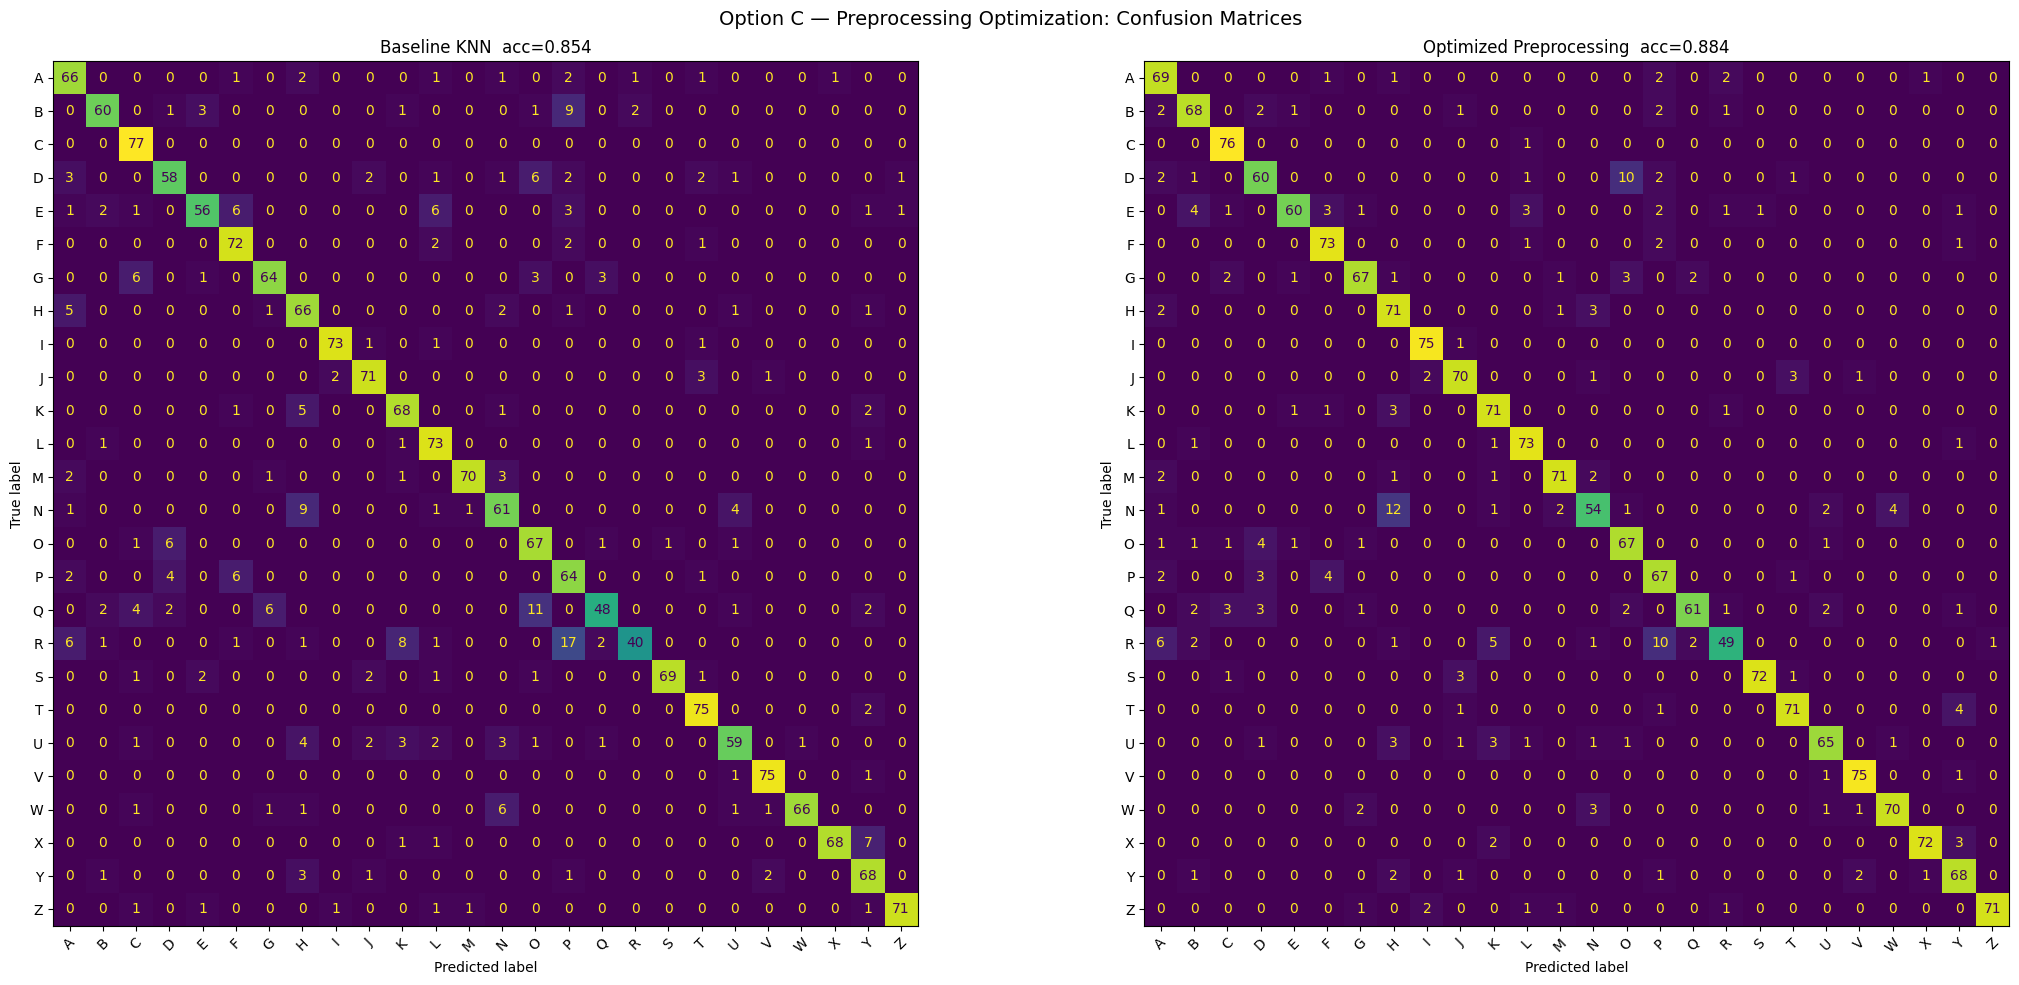

Confusion matrix saved to /content/drive/MyDrive/Models/KNN_OptionC/optionC_confusion_matrix.png


In [13]:
# ── 7. Confusion Matrix ───────────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionC"
os.makedirs(save_dir, exist_ok=True)
labels = [chr(65+i) for i in range(26)]
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, y_p, yt, title in zip(
    axes,
    [y_pred_base, y_pred_best],
    [yte_b,        y_test],
    [f"Baseline KNN  acc={acc_base:.3f}",
     f"Optimized Preprocessing  acc={acc_best:.3f}"]
):
    cm = confusion_matrix(yt, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(title, fontsize=12)

plt.suptitle("Option C — Preprocessing Optimization: Confusion Matrices", fontsize=14)
plt.tight_layout()
cm_path = os.path.join(save_dir, "optionC_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved to {cm_path}")

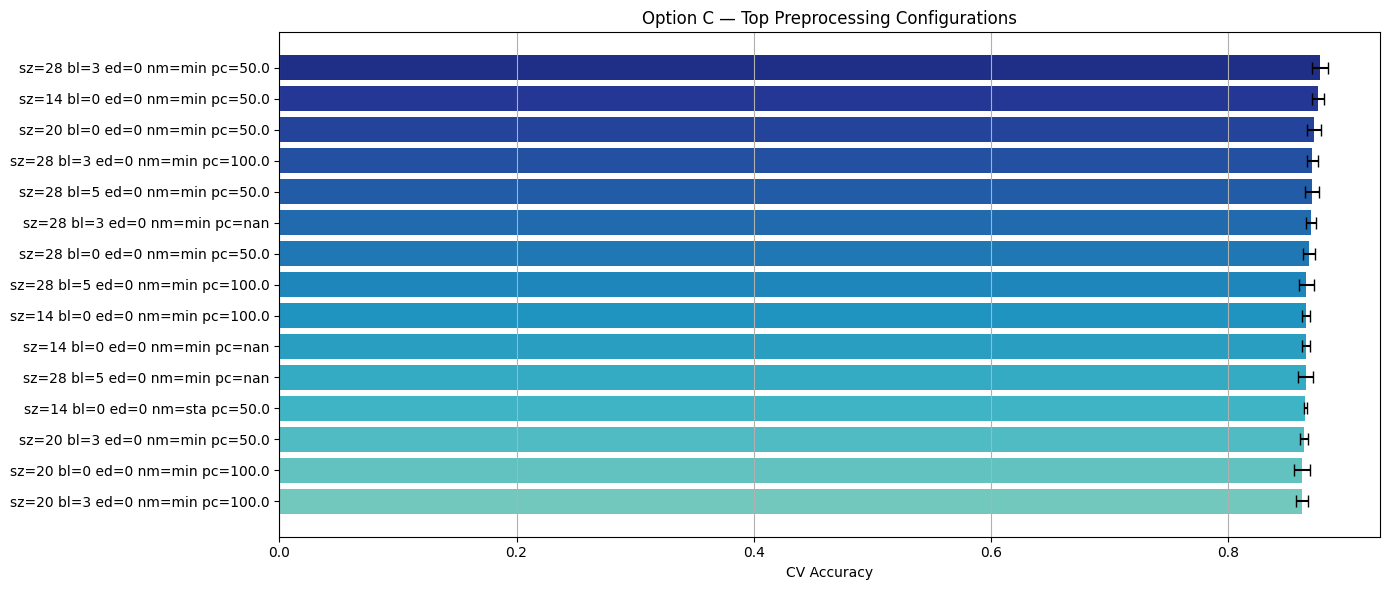

top_configs saved to /content/drive/MyDrive/Models/KNN_OptionC/optionC_top_configs.png


In [15]:
# ── 8. Top configs bar chart ──────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionC"
os.makedirs(save_dir, exist_ok=True)
df_res  = pd.DataFrame(combo_results).sort_values('cv_mean', ascending=False)
top   = df_res.head(15).reset_index(drop=True)
top_labels = [
    f"sz={r.target_size} bl={r.blur_ksize} "
    f"ed={int(r.use_edges)} nm={r.normalizer[:3]} "
    f"pc={r.pca_components if r.pca_components else 'No'}"
    for _, r in top.iterrows()
]
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(top_labels[::-1], top['cv_mean'][::-1],xerr=top['cv_std'][::-1],capsize=4,color=plt.cm.YlGnBu(np.linspace(0.4, 0.9, 15)))
ax.set_xlabel("CV Accuracy")
ax.set_title("Option C — Top Preprocessing Configurations")
ax.grid(axis='x')
plt.tight_layout()
cm_path = os.path.join(save_dir, "optionC_top_configs.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"top_configs saved to {cm_path}")

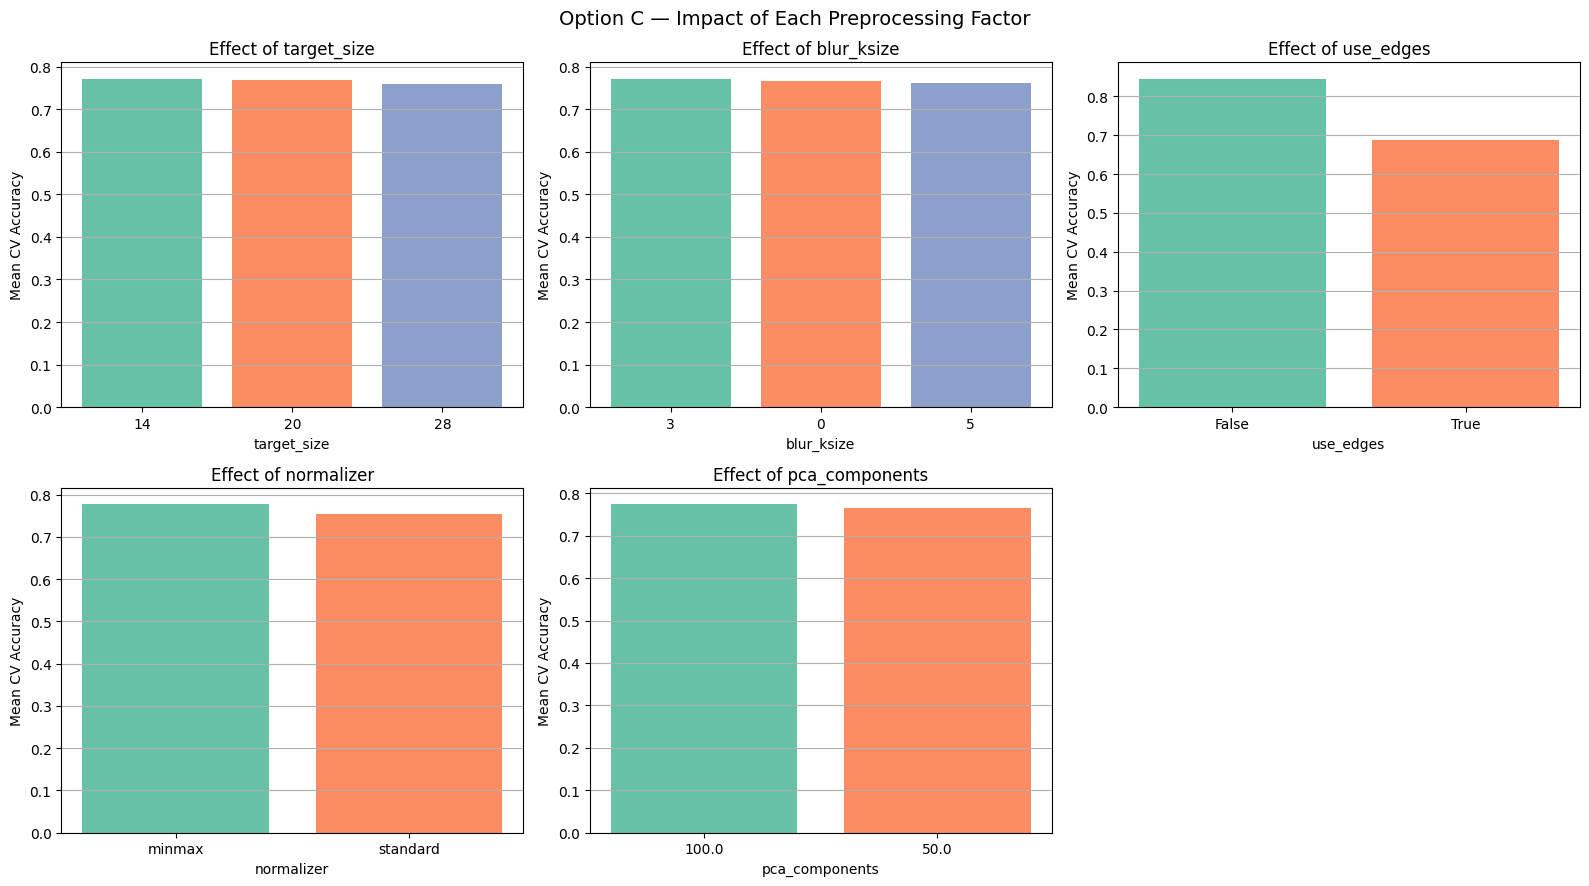

top_configs saved to /content/drive/MyDrive/Models/KNN_OptionC/optionC_factor_effects.png


In [16]:
# ── 9. Effect of each factor ─────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionC"
os.makedirs(save_dir, exist_ok=True)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
factors = ['target_size', 'blur_ksize', 'use_edges','normalizer', 'pca_components']
for i, factor in enumerate(factors):
    grouped = df_res.groupby(factor)['cv_mean'].mean().sort_values(ascending=False)
    axes[i].bar(grouped.index.astype(str), grouped.values,color=plt.cm.Set2.colors[:len(grouped)])
    axes[i].set_title(f"Effect of {factor}")
    axes[i].set_ylabel("Mean CV Accuracy")
    axes[i].set_xlabel(factor)
    axes[i].grid(axis='y')
axes[5].axis('off')
plt.suptitle("Option C — Impact of Each Preprocessing Factor", fontsize=14)
plt.tight_layout()
cm_path = os.path.join(save_dir, "optionC_factor_effects.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"top_configs saved to {cm_path}")

In [18]:
# ── 10.Results & Saving The Model's Results ───────────────────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionC"
os.makedirs(save_dir, exist_ok=True)
print("\n" + "="*55)
print("  OPTION C — RESULTS SUMMARY")
print("="*55)
print(f"  Baseline  acc     : {acc_base:.4f}  (raw 28×28, minmax)")
print(f"  Optimized acc     : {acc_best:.4f}")
print(f"  Best config:")
for k, v in best_config.items():
    print(f"    {k:18s}: {v}")
print(f"  Features used     : {X_best.shape[1]}")
print(f"  Sweep time        : {t_sweep:.1f}s")
print("="*55)
# Save results for final comparison
results_C = {
    'option': 'C - Preprocessing Optimization',
    'accuracy': acc_best,
    'best_config': best_config,
    'report': classification_report(y_test, y_pred_best, output_dict=True,
                                    target_names=[chr(65+i) for i in range(26)])
}
save_path = os.path.join(save_dir, "results_C.npy")
np.save(save_path,results_C)
print(f"Results saved to {save_path}")


  OPTION C — RESULTS SUMMARY
  Baseline  acc     : 0.8538  (raw 28×28, minmax)
  Optimized acc     : 0.8843
  Best config:
    target_size       : 28
    blur_ksize        : 3
    use_edges         : False
    normalizer        : minmax
    pca_components    : 50
  Features used     : 50
  Sweep time        : 170.3s
Results saved to /content/drive/MyDrive/Models/KNN_OptionC/results_C.npy
